In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

In [2]:
np.random.seed(42)
X = np.vstack([
        np.random.normal(loc=[0, 0],   scale=[0.6, 0.4], size=(150, 2)),
        np.random.normal(loc=[0,4],   scale=[0.5, 0.6], size=(50, 2)),
        np.random.normal(loc=[-3, 3],  scale=[0.7, 0.5], size=(250, 2)),
    ])
np.random.shuffle(X)

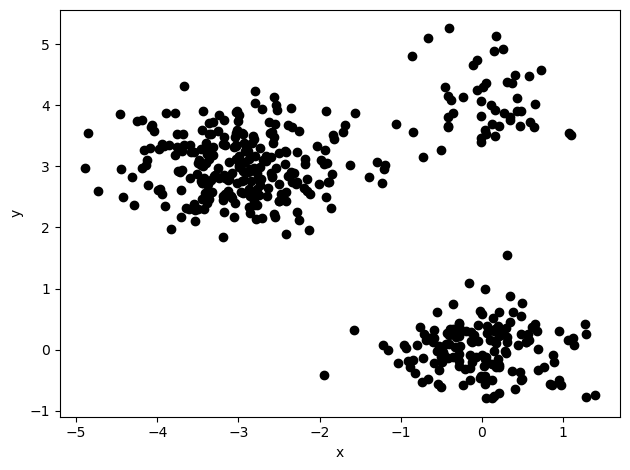

In [3]:
plt.figure()
plt.scatter(*X.T, color="black")
plt.xlabel("x")
plt.ylabel("y")
plt.tight_layout()
plt.show()

In [4]:
def f_cross_2d (a,b):
    return np.abs(a[0]*b[1] - a[1]*b[0])


def f_elbow (k_range, data, plot=True):
    inertia = []
    silhouette = []
    
    for k in k_range:
        km = KMeans(n_clusters=k, random_state=42, algorithm="lloyd",
                   init="random")
        km.fit(data)
        inertia.append(km.inertia_)
        silhouette.append( silhouette_score(data, km.labels_) )
    p_init = np.array([k_range[0], inertia[0]])
    p_end = np.array([k_range[-1], inertia[-1]])
    
    distances = []
    for i in range(len(k_range)):
        p_k = np.array([k_range[i], inertia[i]])
        dist_k = np.abs( f_cross_2d(p_end-p_init,p_end-p_k) ) / np.linalg.norm(p_end-p_init) 
        distances.append(dist_k)
    k_best_inertia = k_range[np.argmax(distances)]
    
    
    k_best_silhouette = k_range[np.argmax(silhouette)]
    

    if plot:
        fig, ax1 = plt.subplots()
        
        ax1.plot(k_range, inertia, "o-",color="darkblue")
        ax1.axvline(x=k_best_inertia,color="darkblue",ls=":",label=r"$k_{inertia}$ =" + str(k_best_inertia))
        ax1.set_ylabel("Inertia")
    
        ax2 = ax1.twinx()
        ax2.plot(k_range, silhouette, "o-",color="orangered")
        ax2.axvline(x=k_best_silhouette,color="orangered",ls=":",label=r"$k_{silhouette}$ =" + str(k_best_silhouette))
        ax2.set_ylabel("Silhouette Score")
    
        plt.xlabel("k")
        
        lines1, labels1 = ax1.get_legend_handles_labels()
        lines2, labels2 = ax2.get_legend_handles_labels()
        ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper right')  
        
        plt.tight_layout()
        plt.show()

    return k_best_inertia, k_best_silhouette
        
        

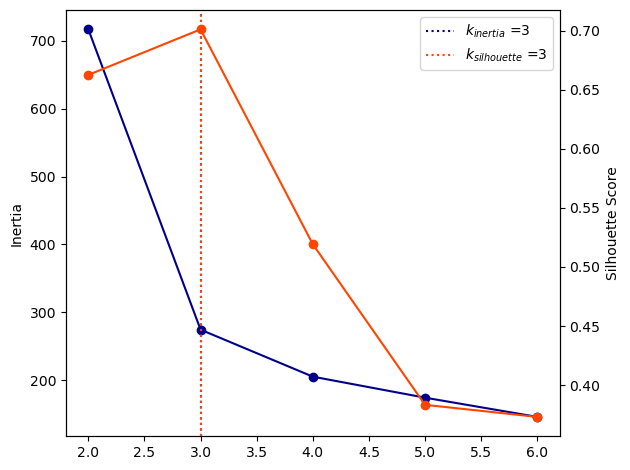

In [5]:
k_range = np.arange(2,7,1)
k_best_inertia, k_best_silhouette = f_elbow(k_range,X)

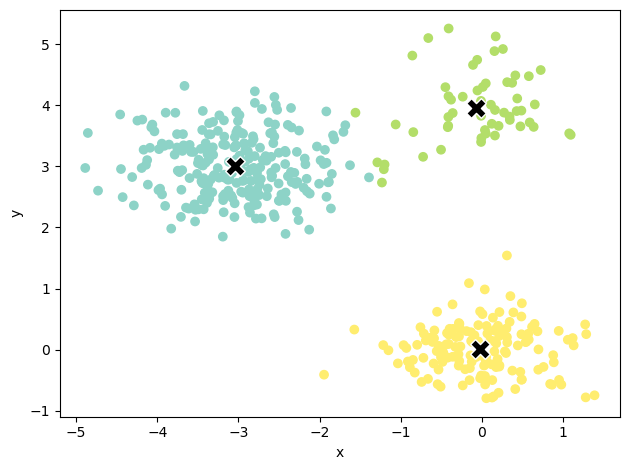

In [6]:
km = KMeans(
    n_clusters=k_best_inertia, random_state=42, 
    algorithm="lloyd", init="random"
)
km.fit(X)

plt.figure()
plt.scatter(*X.T, c=km.labels_, cmap="Set3")
plt.scatter(*km.cluster_centers_.T,s=200, marker="X", edgecolor="white",c="black")
plt.xlabel("x")
plt.ylabel("y")
plt.tight_layout()
plt.show()

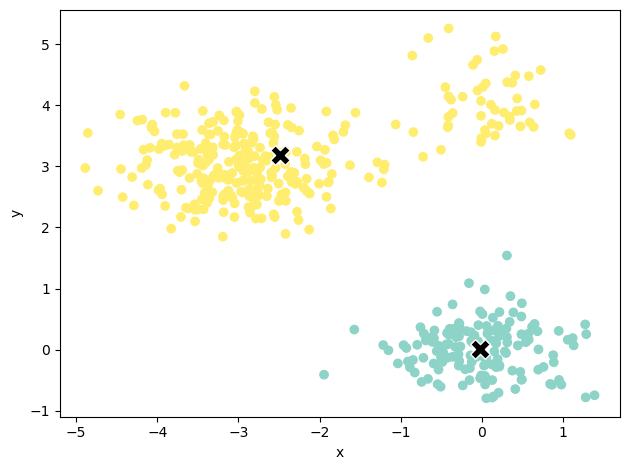

In [7]:
km = KMeans(
    n_clusters=2, random_state=42, 
    algorithm="lloyd", init="random"
)
km.fit(X)

plt.figure()
plt.scatter(*X.T, c=km.labels_,cmap="Set3")
plt.scatter(*km.cluster_centers_.T,s=200, marker="X", edgecolor="white",c="black")
plt.xlabel("x")
plt.ylabel("y")
plt.tight_layout()
plt.show()

In [8]:
def gap_statistic (k_range, data, plot=True, n_trials=20):
    n,m = data.shape
    minims = data.min(axis=0)
    maxs = data.max(axis=0)
    gaps = []
    sk = []
    for k in k_range:
        km = KMeans(n_clusters=k,random_state=42, 
                    algorithm="lloyd", init="random")
        km.fit(data)
        Wk = km.inertia_
        Wk_ref = []
        for i in range(n_trials):
            data_ref = np.random.uniform(minims,maxs, size=(n,m))
            km_ref = KMeans(n_clusters=k,random_state=42, 
                            algorithm="lloyd", init="random")
            km_ref.fit(data_ref)
            Wk_ref.append(km_ref.inertia_)
        log_Wk_ref = np.log(Wk_ref)
        gaps.append( np.mean(log_Wk_ref) - np.log(Wk) )
        sk.append( np.sqrt(np.mean((log_Wk_ref - np.mean(log_Wk_ref))**2)) * np.sqrt(1 + 1/n_trials) )


    k_best = k_range[-1]
    for i in range(1,len(k_range)):
        if gaps[i-1] >= gaps[i] - sk[i]:
            k_best = k_range[i-1]
            break

    if plot:
        plt.figure()
        plt.errorbar(k_range, gaps, yerr=sk, marker="o",color="darkblue")
        plt.axvline(x=k_best,color="orangered",ls=":",label=r"$k_{best}$ =" + str(k_best))
        plt.legend()
        plt.xlabel("k")
        plt.ylabel("G(k)")
        plt.tight_layout()
        plt.show()

    return k_best

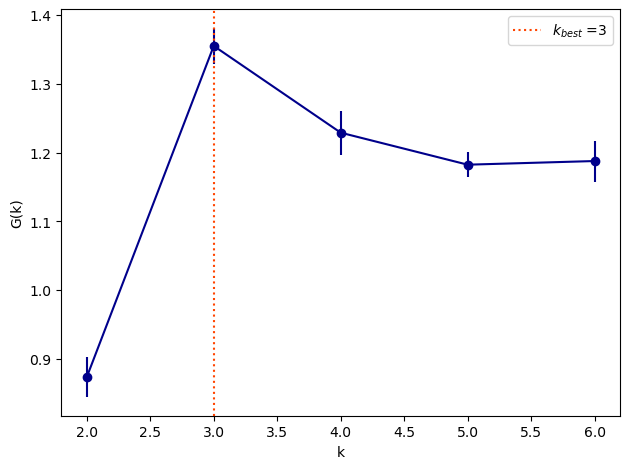

In [9]:
k_range = np.arange(2,7,1)
k_best_gap = gap_statistic(k_range,X)